In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving data_banknote_authentication.csv to data_banknote_authentication.csv


In [4]:
df = pd.read_csv("data_banknote_authentication.csv")
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

In [6]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

In [7]:
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    'max_depth':[2,3,4,5,6],
    'criterion':['gini','entropy'],
    'max_leaf_nodes':[2,5,10,20]
}

grid_dt = GridSearchCV(dt_model, param_grid_dt, cv=5)

grid_dt.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6],
                         'max_leaf_nodes': [2, 5, 10, 20]})

In [8]:
grid_dt.best_params_

{'criterion': 'entropy', 'max_depth': 6, 'max_leaf_nodes': 20}

[[237   1]
 [  1 173]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       238
           1       0.99      0.99      0.99       174

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



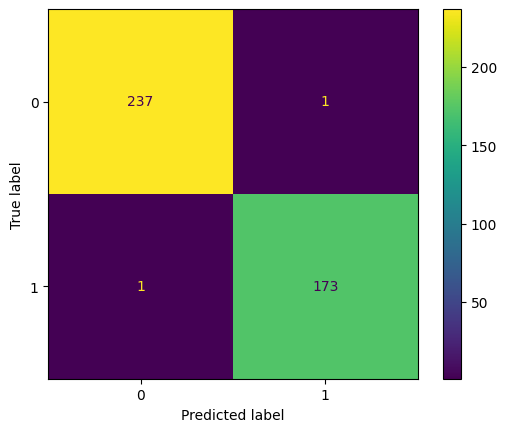

In [9]:
dt_preds = grid_dt.predict(X_test)
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print(confusion_matrix(y_test, dt_preds))
print(classification_report(y_test, dt_preds))

ConfusionMatrixDisplay.from_estimator(grid_dt, X_test, y_test)

In [10]:
from sklearn.ensemble import RandomForestClassifier

In [11]:
rf_model = RandomForestClassifier()

In [13]:
param_grid_rf = {
    'n_estimators':[50,100,200],
    'max_depth':[None,5,10],
    'max_features':['sqrt','log2']
}

In [15]:
from sklearn.model_selection import GridSearchCV

grid_rf = GridSearchCV(rf_model, param_grid_rf, cv=5)

In [16]:
grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [None, 5, 10],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [50, 100, 200]})

In [17]:
grid_rf.best_params_

{'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}

In [18]:
rf_preds = grid_rf.predict(X_test)

[[235   3]
 [  0 174]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       238
           1       0.98      1.00      0.99       174

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



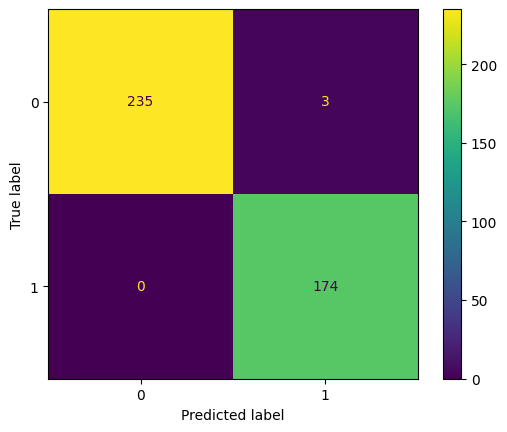

In [19]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print(confusion_matrix(y_test, rf_preds))

print(classification_report(y_test, rf_preds))

ConfusionMatrixDisplay.from_estimator(grid_rf, X_test, y_test)

In [20]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

Decision Tree Accuracy: 0.9951456310679612
Random Forest Accuracy: 0.9927184466019418
